# Word Cloud of "The Adventures of Tom Sawyer"

Load Data: Full text of `The Adventures of Tom Sawyer`

In [1]:
# Note: We can get the online text data using the famous `requests` package!
# You can download the text file directly from URL

# import requests
# response = requests.get("https://www.gutenberg.org/cache/epub/74/pg74.txt")
# text = response.text

# ---

# Or you can read the text file if you have already downloaded it
with open("./data/en_tom_sawyer.txt", "r", encoding="utf-8") as f:
    text = f.read()

print(text[:200])

The Project Gutenberg eBook of The Adventures of Tom Sawyer, Complete
    
This ebook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almos


### 1. Draw Wordcloud (without any text processing)

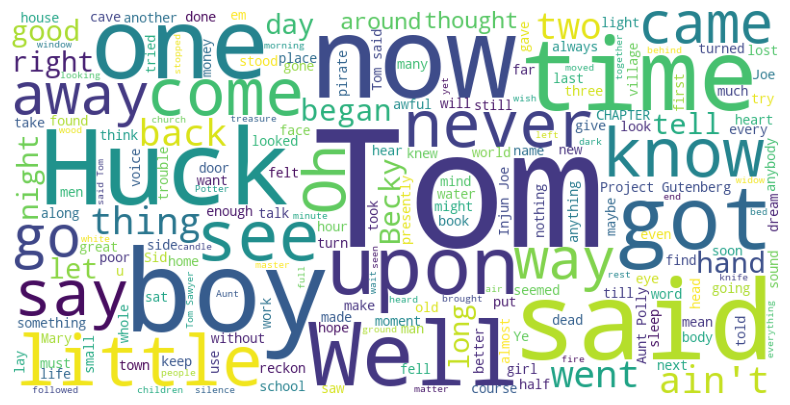

In [2]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

### 2. Draw Wordcloud with an appropriate text processing

In [3]:
import nltk

# If you haven't already, you may need to download the resource
nltk.download('wordnet') # WordNet lemmatizer

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dmlab\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

print(f"The singular of 'things' is: {lemmatizer.lemmatize('things')}")
print(f"The singular of 'mice' is: {lemmatizer.lemmatize('mice')}")

The singular of 'things' is: thing
The singular of 'mice' is: mouse


In [ ]:
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

def get_words(text, custom_stopwords=None):
    text = text.lower()
    
    # tokenization
    words = word_tokenize(text)

    # pos tagging
    tagged = pos_tag(words)
    words = [w for w, pos in tagged if pos[0] == 'N'] # keep only nouns

    # converts a word to its base or dictionary form
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(w) for w in words] # lemmatization

    # remove stopwords
    stop_words_list = stopwords.words('english')
    if custom_stopwords is not None:
        stop_words_list += custom_stopwords  # Add any custom stopwords if needed
    words_filtered = [w for w in words if not w in stop_words_list]
    return words_filtered

In [6]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def draw_wordcloud(word_frequencies_dict):
    wordcloud = WordCloud(width=800, height=400, background_color='white')
    wordcloud = wordcloud.generate_from_frequencies(word_frequencies_dict)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud)
    plt.axis('off')
    plt.show()

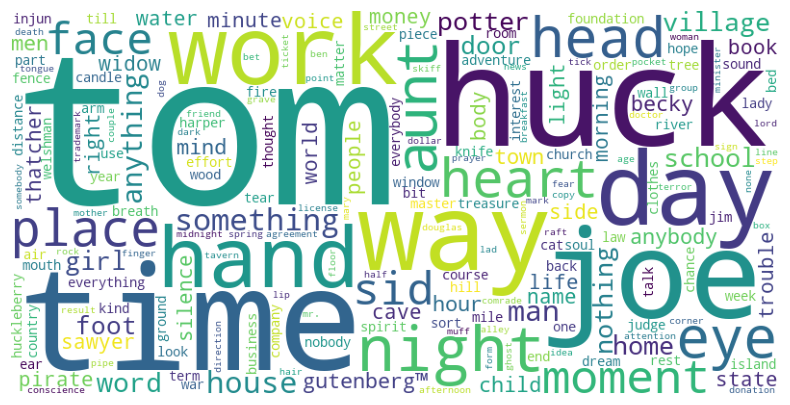

In [8]:
from collections import Counter

custom_stopwords = ['project', 'gutenberg', 'chapter', 'boy', 'thing']

words = get_words(text, custom_stopwords=custom_stopwords)
word_frequencies_dict = Counter(words)
draw_wordcloud(word_frequencies_dict)